In [1]:
import sys
import os
# Add the parent directory to the Python path so we can import utils
sys.path.append(os.path.abspath('..'))

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

import math
from utils import plot_images, widgvis

(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [2]:
print("X_train.shape", X_train.shape)
print("X_test.shape", X_test.shape)
print("y_train.shape", y_train.shape)
print("y_test.shape", y_test.shape)

X_train.shape (60000, 28, 28)
X_test.shape (10000, 28, 28)
y_train.shape (60000,)
y_test.shape (10000,)


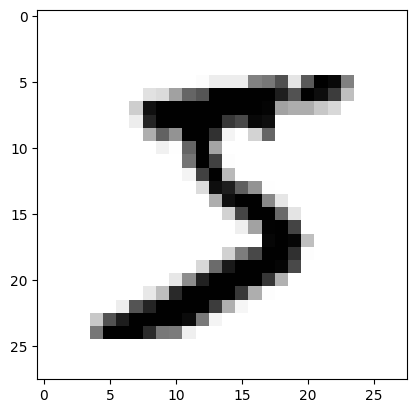

In [3]:
plt.imshow(X_train[0], cmap=plt.cm.binary)
plt.show()

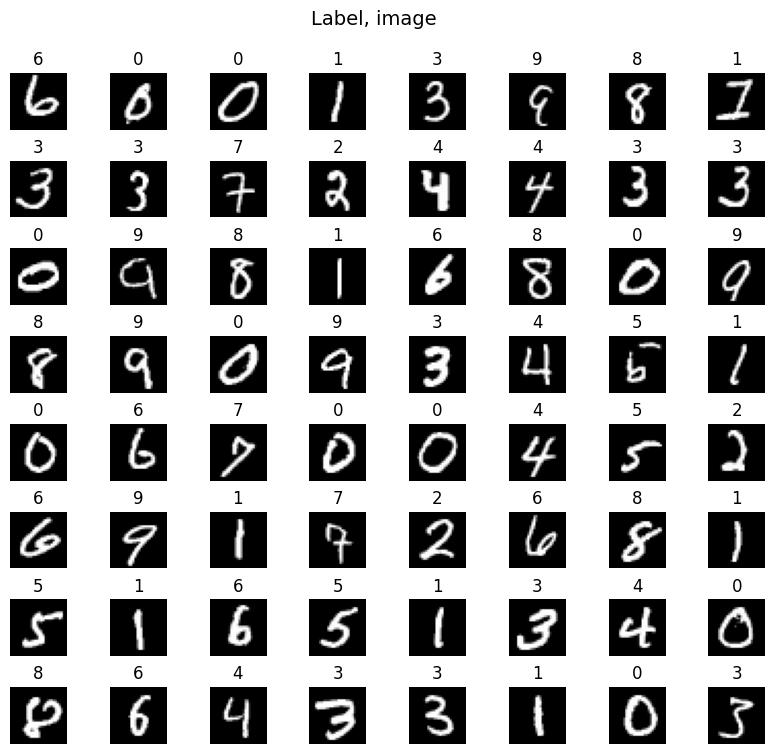

In [18]:
m = X_train.shape[0]

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91]) #[left, bottom, right, top]


#fig.tight_layout(pad=0.5)
widgvis(fig)
for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X_train[random_index]
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Display the label above the image
    ax.set_title(y_train[random_index])
    ax.set_axis_off()
    fig.suptitle("Label, image", fontsize=14)

In [27]:
# Normalize training and test data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Add a channel dimension (for grayscale images)
X_train = X_train[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]

print('X_train shape',X_train.shape)
print('X_test shape',X_test.shape)


X_train shape (60000, 28, 28, 1, 1)
X_test shape (10000, 28, 28, 1, 1)


In [28]:
model = Sequential(
    [
        Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.5),  # Dropout layer to prevent overfitting
        Dense(10, activation="softmax"),  # Output layer for 10 digits (0-9)
    ]
)

# Compile the model
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

# Train the model
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


Epoch 1/10


/Users/mortadhanaser/Desktop/development/apps/learning/handwritten_digit_recognition/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6673 - loss: 0.9828 - val_accuracy: 0.9133 - val_loss: 0.2926
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8672 - loss: 0.4245 - val_accuracy: 0.9441 - val_loss: 0.1842
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9019 - loss: 0.3211 - val_accuracy: 0.9616 - val_loss: 0.1275
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9213 - loss: 0.2607 - val_accuracy: 0.9663 - val_loss: 0.1095
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9316 - loss: 0.2251 - val_accuracy: 0.9704 - val_loss: 0.0917
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9390 - loss: 0.2023 - val_accuracy: 0.9743 - val_loss: 0.0784
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9431 - loss: 0.1854 - val_accuracy: 0.9758 - val_loss: 0.0748
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9482 - loss: 0.1727 - val_accurac

In [29]:
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")
print(f"Test loss: {test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9799 - loss: 0.0670
Test accuracy: 0.9799000024795532
Test loss: 0.06698212772607803


In [31]:
# Save the model
model.save("../models/mnist_cnn.h5")
print("Model saved to models/mnist_cnn.h5")

Model saved to models/mnist_cnn.h5
